In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Singular Value Decomposition

In this notebook, we explore a common application of Singular Value Decomposition (SVD) for dimensionality reduction in image processing. Specifically, we demonstrate how SVD can be used to compress images by reducing their feature space while preserving the essential visual information.

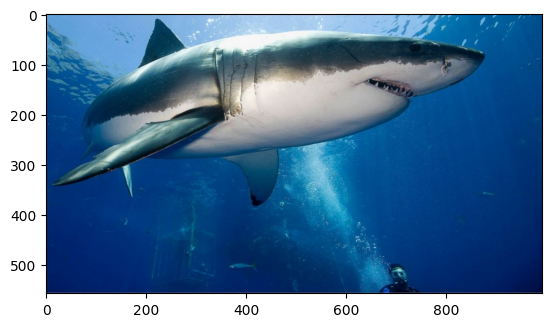

In [4]:
image = Image.open('00000009.jpg')
plt.imshow(image)

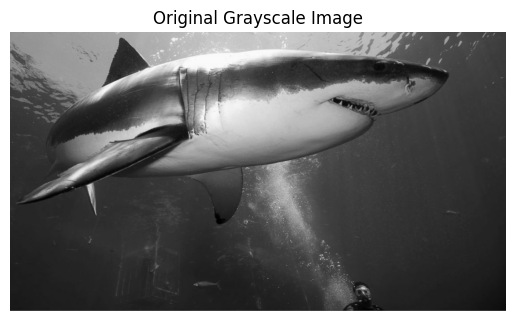

In [5]:
# convert to gray scale
img_gray = image.convert('L')
# Display the grayscale image
plt.imshow(img_gray, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.show()

# Applying Singular Value Decomposition

This is an algebric method usefull to reduce the dimensionality of the data like photos or audio files.

X = U * Σ * Vᵀ

* U , matrix of left singular vectors
* Σ , diagonal matrix of singular values
* Vᵀ , transpose of the matrix of right singular vectors.

In [6]:
# Convert the image to a NumPy array
image_array = np.array(img_gray)
# Apply SVD
U, Sigma, VT = np.linalg.svd(image_array, full_matrices=False)

# Display the shapes of U, Sigma, and VT
print(f'U shape: {U.shape}')
print(f'Sigma shape: {Sigma.shape}')
print(f'VT shape: {VT.shape}')


U shape: (558, 558)
Sigma shape: (558,)
VT shape: (558, 992)


By selecting the top
𝑘
k largest singular values, we can reconstruct an approximation X^
  of the original matrix
X that preserves the most important information while minimizing the reconstruction error.

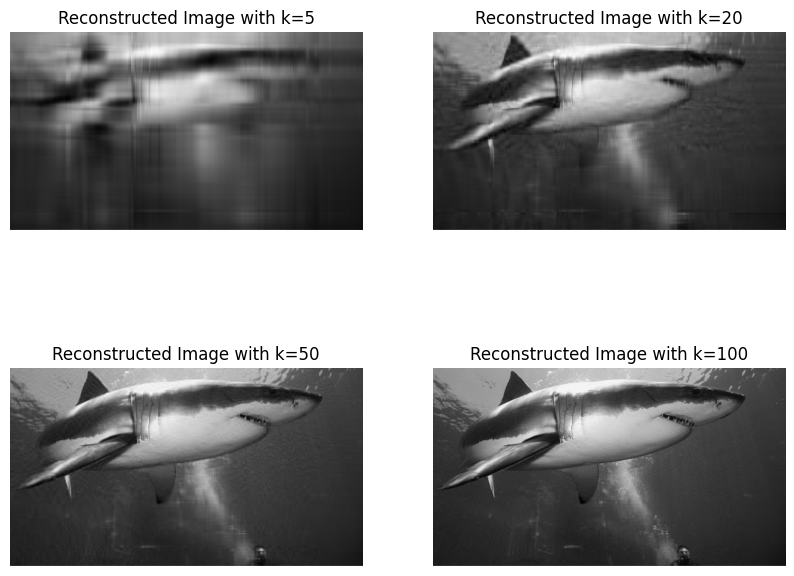

In [7]:
def reconstruct_image(U, Sigma, VT, k):
    # Reconstruct the image using the top k singular values
    Sigma_k = np.diag(Sigma[:k])
    U_k = U[:, :k]
    VT_k = VT[:k, :]
    image_reconstructed = np.dot(U_k, np.dot(Sigma_k, VT_k))

    return image_reconstructed

# Choose the number of singular values
k_values = [5, 20, 50, 100]

# Plot the original and reconstructed images
plt.figure(figsize=(10, 8))
for i, k in enumerate(k_values, 1):
    image_reconstructed = reconstruct_image(U, Sigma, VT, k)
    plt.subplot(2, 2, i)
    plt.imshow(image_reconstructed, cmap='gray')
    plt.title(f'Reconstructed Image with k={k}')
    plt.axis('off')

plt.show()


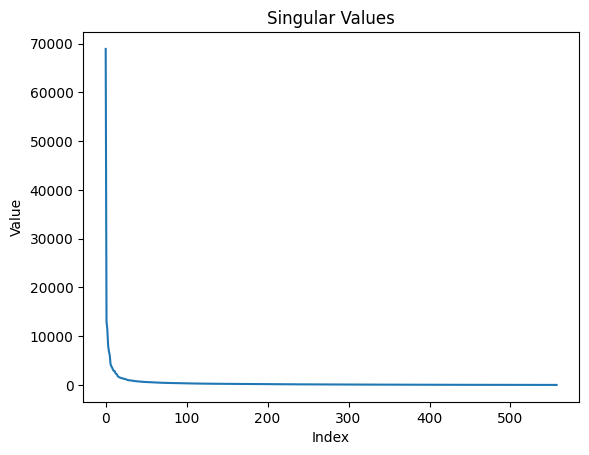

In [8]:
plt.plot(Sigma)
plt.title('Singular Values')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

* The vast majority of the info resides in the first 20 indices.

* The singular values decrease rapidly, so it means that only a few singular vectors are needed to capture the essence of the image

* We can choose the number of k singular values based on the level of dettails we want to obtain.

# Comparison with Fast Fourier Transform (FFT)

Instead of working in the spatial domain, we convert the image into the frequency domain using the Fast Fourier Transform (FFT). <br> This transformation allows us to analyze the image in terms of its frequency components, which represent how rapidly pixel intensities change across the image.

High-frequency components correspond to sharp edges and fine details, while low-frequency components represent smoother areas and general structure.

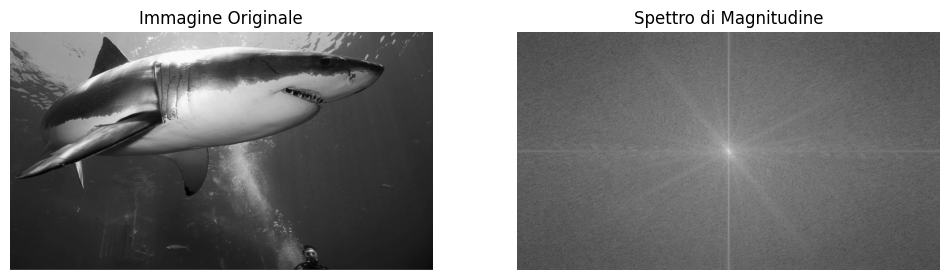

In [9]:
image_array = np.array(img_gray)
# Calcola la FFT dell'immagine
fft_image = np.fft.fft2(image_array)
fft_image_shifted = np.fft.fftshift(fft_image)  # Sposta l'origine al centro

# Calcola la magnitudine della FFT per visualizzare la frequenza
magnitude_spectrum = np.abs(fft_image_shifted)
magnitude_spectrum_log = np.log(magnitude_spectrum + 1)  # Aggiungi 1 per evitare log(0)

# Visualizza l'immagine originale e la magnitudine della FFT
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Immagine Originale')
plt.imshow(image_array, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Spettro di Magnitudine')
plt.imshow(magnitude_spectrum_log, cmap='gray') # Al centro stanno le componenti a bassa frequenza
plt.axis('off')                                 # Verso i bordi le componenti ad alta frequenza (dettagli)

plt.show()

 Compute the magnitude spectrum of the image using FFT. <br>
 The result reveals the strength of spatial frequency components
Low frequencies (image structure) are centered;<br> high frequencies (edges, noise) are close to the borders.

We use the logarithm to compress the dynamic range for better visualization


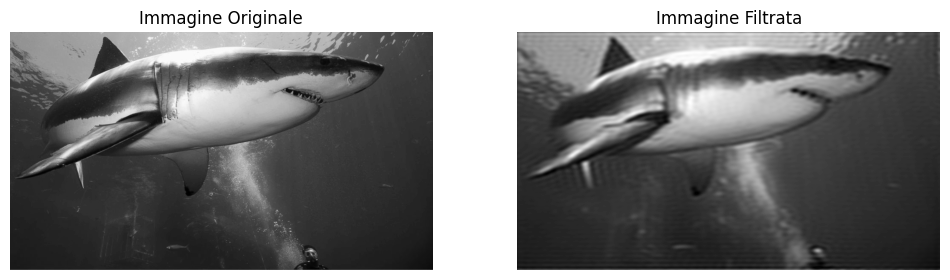

In [ ]:
# Crea un filtro passa-basso (mantieni solo le frequenze basse)
def low_pass_filter(shape, radius):
    center = (shape[0] // 2, shape[1] // 2)
    Y, X = np.ogrid[:shape[0], :shape[1]]
    distance = np.sqrt((X - center[1])**2 + (Y - center[0])**2)
    filter_mask = distance <= radius
    return filter_mask

# Applica il filtro (ad esempio, mantiene solo le frequenze dentro un raggio di 50 pixel)
radius = 50
filter_mask = low_pass_filter(image_array.shape, radius)
fft_filtered = fft_image_shifted * filter_mask

# Calcola la trasformata inversa per ottenere l'immagine filtrata
fft_filtered_shifted = np.fft.ifftshift(fft_filtered)
image_filtered = np.fft.ifft2(fft_filtered_shifted)
image_filtered = np.abs(image_filtered)  # Assicurati che i valori siano positivi

# Visualizza l'immagine originale e quella filtrata
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Immagine Originale')
plt.imshow(image_array, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Immagine Filtrata')
plt.imshow(image_filtered, cmap='gray')
plt.axis('off')

plt.show()

We apply a **low-pass filter** to an image in the frequency domain using FFT.
This involves creating a circular mask that retains only the low-frequency components, effectively **removing** high-frequency details such as edges and noise.
The filtered frequency spectrum is then transformed back to the spatial domain via the inverse FFT, resulting in a smoother, blurred image.

